In [1]:
# untuk untuk upload data dari csv alfamart yang udah di scraping

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# csv upload
from google.colab import files
print("Upload file alfamart_locations.csv dari Task 1")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# clean and normalize province data from OpenMapAPI
province_fix = {
    'Jawabarat': 'Jawa Barat', 'Jawa Bawat': 'Jawa Barat',
    'JawaTimur': 'Jawa Timur', 'DIY': 'DI Yogyakarta',
    'Yogyakarta': 'DI Yogyakarta', 'RI': 'Unknown',
    'kalimantan tengah': 'Kalimantan Tengah', 'Provinsi Papua': 'Papua',
}
df['province'] = df['province'].replace(province_fix)
df = df[df['province'] != 'Unknown'].copy()
df.reset_index(drop=True, inplace=True)

print(f"Data loaded: {len(df):,} stores | {df['province'].nunique()} provinces | {df['city'].nunique()} cities")
df.head(3)


Upload file alfamart_locations.csv dari Task 1


Saving alfamart_locations.csv to alfamart_locations (3).csv
Data loaded: 3,408 stores | 29 provinces | 285 cities


,store_name,full_address,city,province,latitude,longitude,store_type,operating_hours,osm_id,osm_type
0,Alfamart,NaN,Kota Bekasi,Jawa Barat,-6.266326,107.105647,convenience,NaN,895872214,node
1,Alfamart,NaN,Batam,Kepulauan Riau,1.028490,104.061390,convenience,NaN,903291214,node
2,Alfamart,NaN,Bandung Barat,Jawa Barat,-6.865750,107.574506,convenience,NaN,1107474863,node


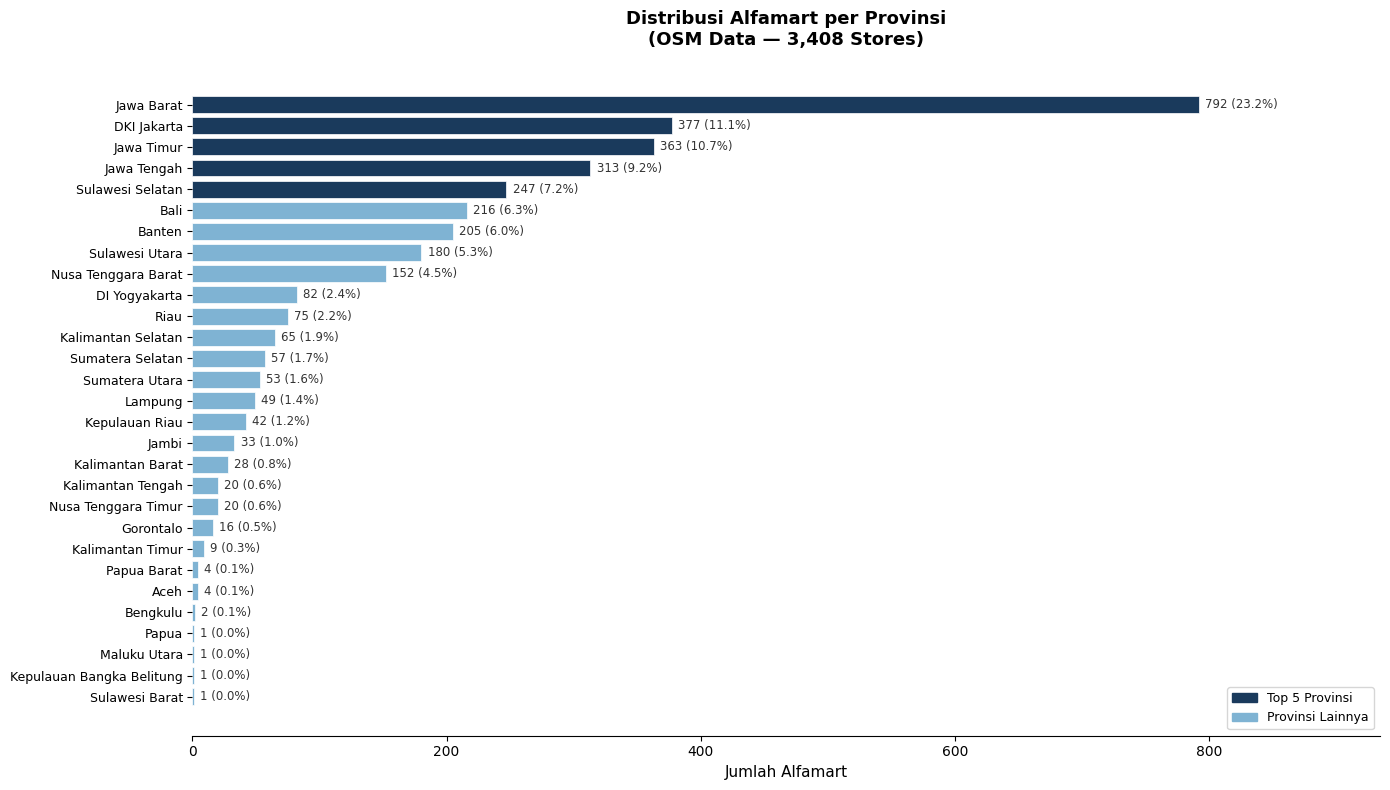


📊 INSIGHT 1: Jawa Barat mendominasi dengan ada nya 790 stores yakni sekitar 23.2% shares. 5 provinsi di Jawa dan Bali menyumbang lebih 60% share total coverage Alfamart di Indonesia.


In [2]:
# chart 1, store count per province

prov_count = df['province'].value_counts().reset_index()
prov_count.columns = ['province', 'count']
prov_count['pct'] = prov_count['count'] / prov_count['count'].sum() * 100

# color: top 5 province = dark blue, other than top 5 = light blue
colors = ['#1a3a5c' if i < 5 else '#7fb3d3' for i in range(len(prov_count))]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(prov_count['province'][::-1], prov_count['count'][::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)

# value labels
for bar, val, pct in zip(bars, prov_count['count'][::-1], prov_count['pct'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=8.5, color='#333')

ax.set_xlabel('Jumlah Alfamart', fontsize=11)
ax.set_title('Distribusi Alfamart per Provinsi\n(OSM Data — 3,408 Stores)', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
ax.set_xlim(0, prov_count['count'].max() * 1.18)

top5 = mpatches.Patch(color='#1a3a5c', label='Top 5 Provinsi')
rest = mpatches.Patch(color='#7fb3d3', label='Provinsi Lainnya')
ax.legend(handles=[top5, rest], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_province_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 INSIGHT 1: Jawa Barat mendominasi dengan ada nya 790 stores yakni sekitar 23.2% shares. "
      "5 provinsi di Jawa dan Bali menyumbang lebih 60% share total coverage Alfamart di Indonesia.")


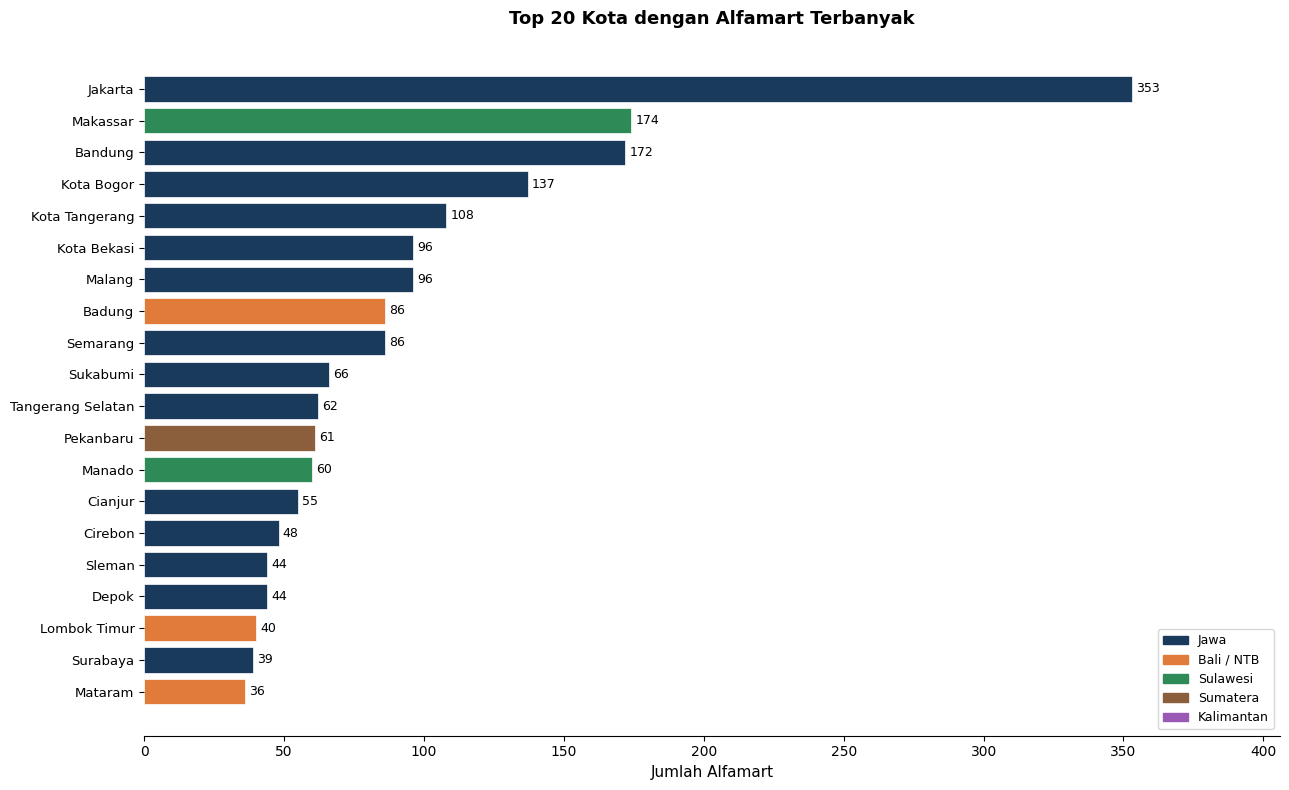


📊 INSIGHT 2: Jakarta memiliki 353 alfamart store. Makassar masuk top 5 dengan 174 alfamart store — sinyal kuat ekspansi Alfamart ke Indonesia Timur.


In [3]:
# chart : top 20 cities, top 20 kota
city_count = df['city'].value_counts().head(20).reset_index()
city_count.columns = ['city', 'count']

# gabungin province info untuk warna per pulau di indonesia
city_prov = df.groupby('city')['province'].agg(lambda x: x.mode()[0]).reset_index()
city_count = city_count.merge(city_prov, on='city')

island_color = {
    'Jawa Barat': '#1a3a5c', 'DKI Jakarta': '#1a3a5c', 'Jawa Timur': '#1a3a5c',
    'Jawa Tengah': '#1a3a5c', 'Banten': '#1a3a5c', 'DI Yogyakarta': '#1a3a5c',
    'Bali': '#e07b39', 'Nusa Tenggara Barat': '#e07b39',
    'Sulawesi Selatan': '#2e8b57', 'Sulawesi Utara': '#2e8b57',
    'Sumatera Utara': '#8b5e3c', 'Sumatera Selatan': '#8b5e3c',
    'Riau': '#8b5e3c', 'Lampung': '#8b5e3c',
    'Kalimantan Selatan': '#9b59b6',
}
city_count['color'] = city_count['province'].map(island_color).fillna('#aaa')

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(city_count['city'][::-1], city_count['count'][::-1],
               color=city_count['color'][::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, city_count['count'][::-1]):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Jumlah Alfamart', fontsize=11)
ax.set_title('Top 20 Kota dengan Alfamart Terbanyak', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=9.5)
ax.set_xlim(0, city_count['count'].max() * 1.15)

legend_items = [
    mpatches.Patch(color='#1a3a5c', label='Jawa'),
    mpatches.Patch(color='#e07b39', label='Bali / NTB'),
    mpatches.Patch(color='#2e8b57', label='Sulawesi'),
    mpatches.Patch(color='#8b5e3c', label='Sumatera'),
    mpatches.Patch(color='#9b59b6', label='Kalimantan'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_top_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 INSIGHT 2: Jakarta memiliki 353 alfamart store. "
      "Makassar masuk top 5 dengan 174 alfamart store — sinyal kuat ekspansi Alfamart ke Indonesia Timur.")


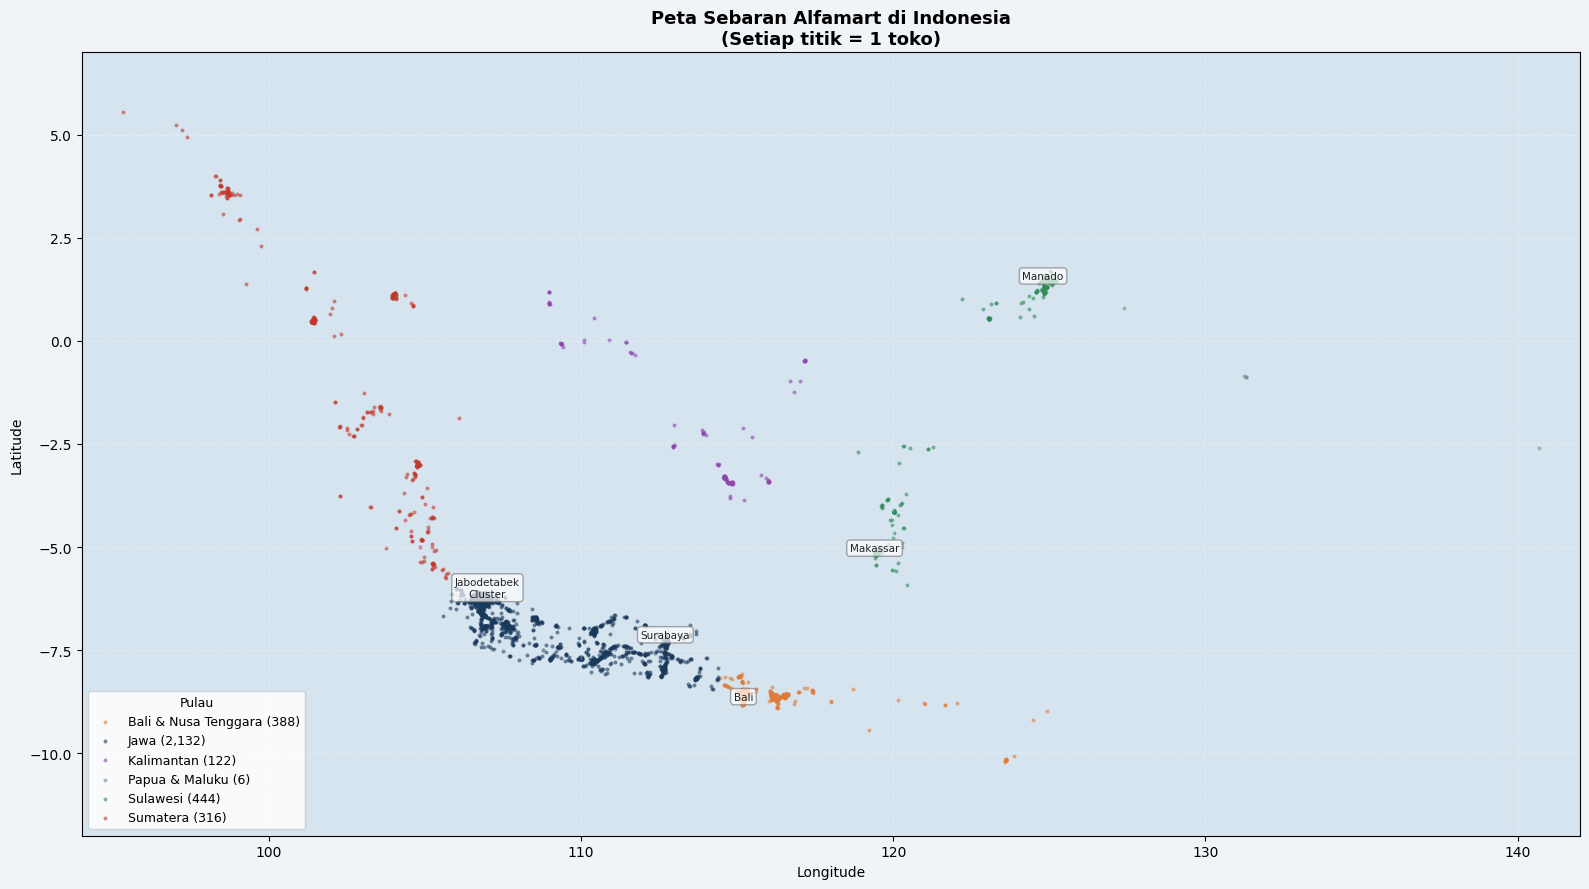


📊 INSIGHT 3: Density Pulau Jawa sangat tinggi — titik hampir solid di Jabodetabek & Surabaya. Kalimantan & Papua sangat kosong = wbisa jadi opportunity untuk ekspansi.


In [4]:
# chart scatter plot map
# grouping pulau untuk warna
def assign_island(prov):
    jawa = ['Jawa Barat','DKI Jakarta','Jawa Timur','Jawa Tengah','Banten','DI Yogyakarta']
    bali_nusa = ['Bali','Nusa Tenggara Barat','Nusa Tenggara Timur']
    sulawesi = [p for p in df['province'].unique() if 'Sulawesi' in p or p == 'Gorontalo']
    sumatera = [p for p in df['province'].unique() if any(k in p for k in ['Sumatera','Aceh','Riau','Lampung','Jambi','Bengkulu','Bangka'])]
    kalimantan = [p for p in df['province'].unique() if 'Kalimantan' in p]
    if prov in jawa: return 'Jawa'
    if prov in bali_nusa: return 'Bali & Nusa Tenggara'
    if prov in sulawesi: return 'Sulawesi'
    if prov in sumatera: return 'Sumatera'
    if prov in kalimantan: return 'Kalimantan'
    return 'Papua & Maluku'

df['island'] = df['province'].apply(assign_island)

island_palette = {
    'Jawa': '#1a3a5c',
    'Bali & Nusa Tenggara': '#e07b39',
    'Sulawesi': '#2e8b57',
    'Sumatera': '#c0392b',
    'Kalimantan': '#8e44ad',
    'Papua & Maluku': '#7f8c8d',
}

fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor('#f0f4f8')
ax.set_facecolor('#d6e4f0')

for island, grp in df.groupby('island'):
    ax.scatter(grp['longitude'], grp['latitude'],
               c=island_palette[island], s=8, alpha=0.6,
               label=f"{island} ({len(grp):,})", linewidths=0)

ax.set_xlim(94, 142)
ax.set_ylim(-12, 7)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title('Peta Sebaran Alfamart di Indonesia\n(Setiap titik = 1 toko)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9, framealpha=0.85, title='Pulau', title_fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3, color='white')

annotations = [
    (107.0, -6.2, 'Jabodetabek\nCluster'),
    (112.7, -7.2, 'Surabaya'),
    (115.2, -8.7, 'Bali'),
    (119.4, -5.1, 'Makassar'),
    (124.8,  1.5, 'Manado'),
]
for lon, lat, label in annotations:
    ax.annotate(label, (lon, lat), fontsize=7.5, color='#222',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='gray'),
                ha='center')

plt.tight_layout()
plt.savefig('chart3_geo_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 INSIGHT 3: Density Pulau Jawa sangat tinggi — titik hampir solid di Jabodetabek & Surabaya. "
      "Kalimantan & Papua sangat kosong = wbisa jadi opportunity untuk ekspansi.")


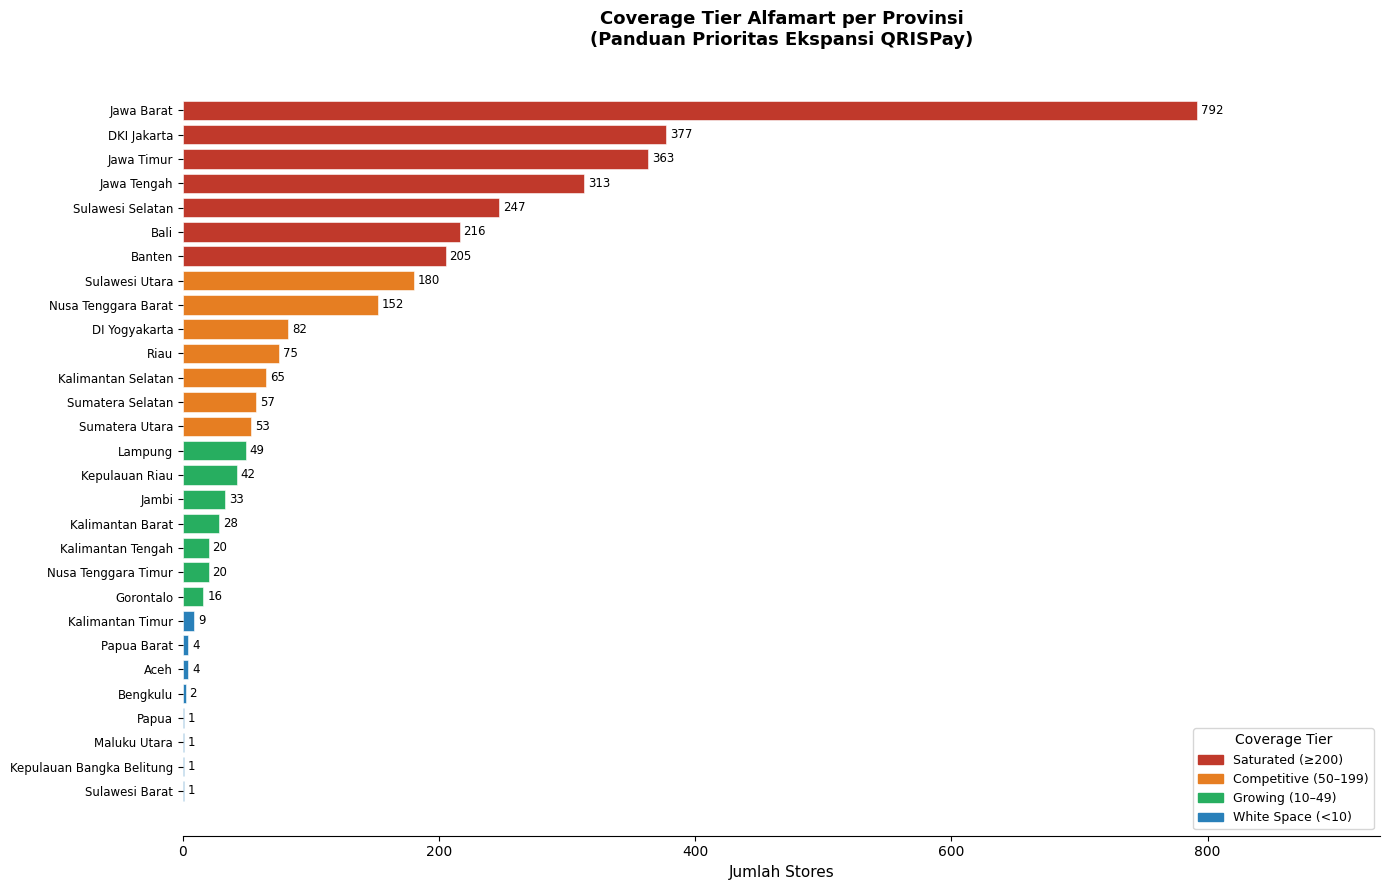


📊 INSIGHT 4 — Coverage Tier Summary:
  [Competitive (50–199)] → Sulawesi Utara, Nusa Tenggara Barat, DI Yogyakarta, Riau, Kalimantan Selatan, Sumatera Selatan, Sumatera Utara
  [Growing (10–49)] → Lampung, Kepulauan Riau, Jambi, Kalimantan Barat, Kalimantan Tengah, Nusa Tenggara Timur, Gorontalo
  [Saturated (≥200)] → Jawa Barat, DKI Jakarta, Jawa Timur, Jawa Tengah, Sulawesi Selatan, Bali, Banten
  [White Space (<10)] → Kalimantan Timur, Papua Barat, Aceh, Bengkulu, Papua, Maluku Utara, Kepulauan Bangka Belitung, Sulawesi Barat


In [5]:
# chart 4 intensity coverage store per provinsi
from matplotlib.colors import LinearSegmentedColormap

prov_df = df['province'].value_counts().reset_index()
prov_df.columns = ['province', 'count']
prov_df['pct'] = prov_df['count'] / prov_df['count'].sum() * 100

# tier classification
def tier(n):
    if n >= 200: return 'Saturated (≥200)'
    if n >= 50:  return 'Competitive (50–199)'
    if n >= 10:  return 'Growing (10–49)'
    return 'White Space (<10)'

prov_df['tier'] = prov_df['count'].apply(tier)
tier_colors = {
    'Saturated (≥200)':    '#c0392b',
    'Competitive (50–199)':'#e67e22',
    'Growing (10–49)':     '#27ae60',
    'White Space (<10)':   '#2980b9',
}
prov_df['color'] = prov_df['tier'].map(tier_colors)

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(prov_df['province'][::-1], prov_df['count'][::-1],
               color=prov_df['color'][::-1], edgecolor='white', linewidth=0.4)

for bar, val, tier_val in zip(bars, prov_df['count'][::-1], prov_df['tier'][::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8.5)

ax.set_xlabel('Jumlah Stores', fontsize=11)
ax.set_title('Coverage Tier Alfamart per Provinsi\n(Panduan Prioritas Ekspansi QRISPay)', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=8.5)
ax.set_xlim(0, prov_df['count'].max() * 1.18)

legend_items = [mpatches.Patch(color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_items, title='Coverage Tier', loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_coverage_tier.png', dpi=150, bbox_inches='tight')
plt.show()

# print tier summary
print("\n📊 INSIGHT 4 — Coverage Tier Summary:")
for tier_name, grp in prov_df.groupby('tier'):
    provs = ', '.join(grp['province'].tolist())
    print(f"  [{tier_name}] → {provs}")


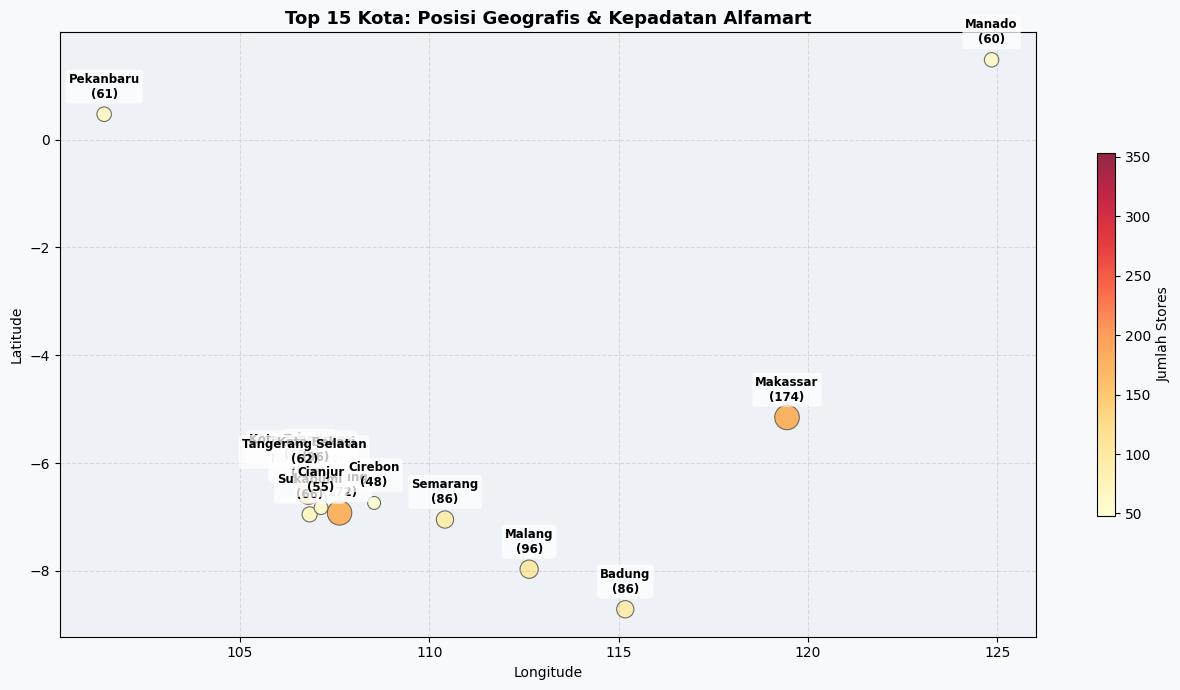


📊 INSIGHT 5: Kota di pulau Jawa (kiri) sangat padat vs kota luar Jawa yang memiliki cluster sedikit. Ini menunjukkan perlu strategi berbeda untuk penetration di Jawa vs di luar Jawa.


In [6]:
# chart top 15 city
top_cities = df['city'].value_counts().head(15).reset_index()
top_cities.columns = ['city', 'count']
top_cities = top_cities.merge(
    df.groupby('city')[['latitude','longitude']].median().reset_index(), on='city'
)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#eef2f7')

scatter = ax.scatter(
    top_cities['longitude'], top_cities['latitude'],
    s=top_cities['count'] * 1.8,
    c=top_cities['count'],
    cmap='YlOrRd', alpha=0.85, edgecolors='#555', linewidths=0.8
)

for _, row in top_cities.iterrows():
    ax.annotate(f"{row['city']}\n({row['count']})",
                (row['longitude'], row['latitude']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75, ec='none'))

plt.colorbar(scatter, ax=ax, label='Jumlah Stores', shrink=0.6)
ax.set_title('Top 15 Kota: Posisi Geografis & Kepadatan Alfamart', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart5_city_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 INSIGHT 5: Kota di pulau Jawa (kiri) sangat padat vs kota luar Jawa yang memiliki cluster sedikit. "
      "Ini menunjukkan perlu strategi berbeda untuk penetration di Jawa vs di luar Jawa.")


In [7]:
# untuk export ke excel

from openpyxl import Workbook
from openpyxl.styles import (Font, PatternFill, Alignment, Border, Side,
                              GradientFill)
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, Reference
from openpyxl.chart.series import DataPoint
import openpyxl

wb = Workbook()

# ── Shared styles ──────────────────────────────────────────────────────────────
HDR_FILL   = PatternFill('solid', start_color='1A3A5C')
HDR_FONT   = Font(bold=True, color='FFFFFF', name='Arial', size=10)
BODY_FONT  = Font(name='Arial', size=9)
ALT_FILL   = PatternFill('solid', start_color='EBF2FA')
thin       = Side(style='thin', color='CCCCCC')
BORDER     = Border(left=thin, right=thin, top=thin, bottom=thin)
CENTER     = Alignment(horizontal='center', vertical='center')
LEFT       = Alignment(horizontal='left',   vertical='center')

def style_header_row(ws, row, cols):
    for c in range(1, cols + 1):
        cell = ws.cell(row=row, column=c)
        cell.fill, cell.font, cell.alignment, cell.border = HDR_FILL, HDR_FONT, CENTER, BORDER

def style_data_rows(ws, start_row, end_row, cols):
    for r in range(start_row, end_row + 1):
        fill = ALT_FILL if r % 2 == 0 else PatternFill('solid', start_color='FFFFFF')
        for c in range(1, cols + 1):
            cell = ws.cell(row=r, column=c)
            cell.fill, cell.font, cell.border = fill, BODY_FONT, BORDER
            cell.alignment = CENTER if c > 1 else LEFT

# Sheet 1 Raw Data
ws1 = wb.active
ws1.title = 'Raw Data'
headers = ['store_name','full_address','city','province','latitude','longitude',
           'store_type','operating_hours','osm_id','osm_type']
ws1.append(headers)
for row in df[headers].itertuples(index=False):
    ws1.append(list(row))

style_header_row(ws1, 1, len(headers))
style_data_rows(ws1, 2, len(df) + 1, len(headers))
col_widths = [15, 35, 20, 22, 12, 12, 14, 22, 14, 10]
for i, w in enumerate(col_widths, 1):
    ws1.column_dimensions[get_column_letter(i)].width = w
ws1.freeze_panes = 'A2'

# Sheet 2 Province Summary
ws2 = wb.create_sheet('Province Summary')
prov_sum = df['province'].value_counts().reset_index()
prov_sum.columns = ['Province', 'Store Count']
prov_sum.insert(0, 'Rank', range(1, len(prov_sum) + 1))
prov_sum['% of Total'] = '=C{}/SUM($C$2:$C${})'.format(0, 0)  # placeholder

ws2.append(['Rank', 'Province', 'Store Count', '% of Total', 'Coverage Tier'])
for i, (_, row) in enumerate(prov_sum.iterrows(), 2):
    count = row['Store Count']
    tier = ('Saturated' if count >= 200 else
            'Competitive' if count >= 50 else
            'Growing' if count >= 10 else 'White Space')
    ws2.append([
        row['Rank'], row['Province'], count,
        f'=C{i}/SUM($C$2:$C${len(prov_sum)+1})',
        tier
    ])

style_header_row(ws2, 1, 5)
style_data_rows(ws2, 2, len(prov_sum) + 1, 5)

# color tier cells
tier_colors_xl = {
    'Saturated':   'C0392B', 'Competitive': 'E67E22',
    'Growing':     '27AE60', 'White Space': '2980B9',
}
for r in range(2, len(prov_sum) + 2):
    cell = ws2.cell(row=r, column=5)
    color = tier_colors_xl.get(cell.value, 'AAAAAA')
    cell.fill = PatternFill('solid', start_color=color)
    cell.font = Font(name='Arial', size=9, color='FFFFFF', bold=True)
    cell.alignment = CENTER

# % column format
for r in range(2, len(prov_sum) + 2):
    ws2.cell(row=r, column=4).number_format = '0.0%'

for col, w in zip('ABCDE', [8, 30, 14, 14, 16]):
    ws2.column_dimensions[col].width = w
ws2.freeze_panes = 'A2'

# bar chart on Province Summary
chart = BarChart()
chart.type = 'bar'
chart.title = 'Store Count per Province'
chart.y_axis.title = 'Province'
chart.x_axis.title = 'Stores'
chart.style = 10
chart.width, chart.height = 20, 14

data_ref  = Reference(ws2, min_col=3, min_row=1, max_row=len(prov_sum) + 1)
cats_ref  = Reference(ws2, min_col=2, min_row=2, max_row=len(prov_sum) + 1)
chart.add_data(data_ref, titles_from_data=True)
chart.set_categories(cats_ref)
ws2.add_chart(chart, 'G2')

# sheet 3 City Summary
ws3 = wb.create_sheet('City Summary')
city_sum = df['city'].value_counts().head(30).reset_index()
city_sum.columns = ['City', 'Store Count']
city_sum.insert(0, 'Rank', range(1, len(city_sum) + 1))

city_prov_map = df.groupby('city')['province'].agg(lambda x: x.mode()[0])
city_sum['Province'] = city_sum['City'].map(city_prov_map)

ws3.append(['Rank', 'City', 'Province', 'Store Count'])
for _, row in city_sum.iterrows():
    ws3.append([row['Rank'], row['City'], row['Province'], row['Store Count']])

style_header_row(ws3, 1, 4)
style_data_rows(ws3, 2, len(city_sum) + 1, 4)
for col, w in zip('ABCD', [8, 24, 24, 14]):
    ws3.column_dimensions[col].width = w
ws3.freeze_panes = 'A2'

# sheet 4 island summary
ws4 = wb.create_sheet('Island Summary')
island_sum = df['island'].value_counts().reset_index()
island_sum.columns = ['Island Group', 'Store Count']
island_sum['% of Total'] = None
island_sum['Priority for QRISPay'] = island_sum['Island Group'].map({
    'Jawa':                 'Penetration — high density, defend share',
    'Bali & Nusa Tenggara': 'Penetration — tourism corridor, high txn value',
    'Sulawesi':             'Growth — Makassar as anchor, expand east',
    'Sumatera':             'Growth — Medan & Palembang anchor cities',
    'Kalimantan':           'Pioneer — low coverage, first-mover advantage',
    'Papua & Maluku':       'Pioneer — minimal presence, long-term play',
})

ws4.append(['Island Group', 'Store Count', '% of Total', 'QRISPay Priority Strategy'])
for i, (_, row) in enumerate(island_sum.iterrows(), 2):
    ws4.append([
        row['Island Group'], row['Store Count'],
        f'=B{i}/SUM($B$2:$B${len(island_sum)+1})',
        row['Priority for QRISPay']
    ])

style_header_row(ws4, 1, 4)
style_data_rows(ws4, 2, len(island_sum) + 1, 4)
for r in range(2, len(island_sum) + 2):
    ws4.cell(row=r, column=3).number_format = '0.0%'
for col, w in zip('ABCD', [28, 14, 14, 52]):
    ws4.column_dimensions[col].width = w

# sheet 5 insights
ws5 = wb.create_sheet('Key Insights')
ws5.column_dimensions['A'].width = 18
ws5.column_dimensions['B'].width = 80

insights = [
    ('INSIGHT', 'DETAIL'),
    ('Coverage Dominance',
     'Jawa Barat (790), DKI Jakarta (377), Jawa Timur (362) = 45% total stores. '
     'Competitor sangat kuat di Jawa — QRISPay harus match coverage atau differentiate by service quality.'),
    ('Sulawesi Surprise',
     'Sulawesi Selatan (247) + Sulawesi Utara (180) = 427 stores — lebih banyak dari Jawa Tengah (313). '
     'Alfamart sudah agresif di Sulawesi. QRISPay perlu masuk cepat sebelum eksklusivitas terbentuk.'),
    ('Kalimantan White Space',
     'Total Kalimantan hanya ~122 stores (3.6%). Dengan populasi & ekonomi Kaltim yang tumbuh '
     '(IKN), ini adalah opportunity terbesar untuk first-mover advantage QRISPay.'),
    ('Bali High-Value Corridor',
     '216 stores di Bali — density tinggi untuk pulau kecil. Tourist traffic = high transaction '
     'value & frequency. QRISPay harus prioritaskan Bali sebagai showcase market.'),
    ('City Concentration Risk',
     'Top 5 kota = ~30% total stores. Over-reliance pada Jabodetabek & Surabaya. '
     'QRISPay field sales sebaiknya juga target tier-2 cities (Makassar, Denpasar, Manado).'),
    ('Data Coverage Note',
     'Data OSM bersifat community-contributed — kemungkinan under-represent di daerah rural. '
     'Actual Alfamart network ~18.000 stores (per annual report 2023). '
     'Dataset ini ~19% dari total — cukup representatif untuk analisis distribusi geografis.'),
]

for r, (title, detail) in enumerate(insights, 1):
    ws5.cell(row=r, column=1).value = title
    ws5.cell(row=r, column=2).value = detail
    if r == 1:
        ws5.cell(row=r, column=1).font = HDR_FONT
        ws5.cell(row=r, column=1).fill = HDR_FILL
        ws5.cell(row=r, column=2).font = HDR_FONT
        ws5.cell(row=r, column=2).fill = HDR_FILL
    else:
        fill = ALT_FILL if r % 2 == 0 else PatternFill('solid', start_color='FFFFFF')
        for c in [1, 2]:
            cell = ws5.cell(row=r, column=c)
            cell.fill = fill
            cell.font = Font(name='Arial', size=9)
            cell.alignment = Alignment(wrap_text=True, vertical='top')
            cell.border = BORDER
    ws5.row_dimensions[r].height = 55 if r > 1 else 18

output_xlsx = 'alfamart_analysis.xlsx'
wb.save(output_xlsx)
print(f"Excel saved: {output_xlsx}")
print("Sheets: Raw Data | Province Summary | City Summary | Island Summary | Key Insights")


Excel saved: alfamart_analysis.xlsx
Sheets: Raw Data | Province Summary | City Summary | Island Summary | Key Insights


In [8]:
from google.colab import files

print("Downloading all outputs...")
for f in ['alfamart_analysis.xlsx',
          'chart1_province_distribution.png',
          'chart2_top_cities.png',
          'chart3_geo_scatter.png',
          'chart4_coverage_tier.png',
          'chart5_city_bubble.png']:
    files.download(f)
    print(f"  ✓ {f}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ alfamart_analysis.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ chart4_coverage_tier.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ chart5_city_bubble.png
